In [1]:
import os
import sys
import glob

import numpy as np
from cora.util import units

from draco.util import tools
from fitstack import containers

In [2]:
import getdist
from getdist import plots, MCSamples

Matplotlib created a temporary cache directory at /tmp/matplotlib-llnjbumc because the default path (/home/h/halpern/arnab92/.config/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [3]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.backends.backend_pdf import PdfPages
%matplotlib inline

In [4]:
from draco.core.containers import FrequencyStack, FrequencyStackByPol, MockFrequencyStack, FormedBeam

In [5]:
import h5py
import getdist
from getdist import plots, MCSamples, chains, mcsamples
from cora.signal.lssmodels import bias
from cora.signal.lssmodels import omega_HI
from cora.signal import corr21cm
from cora.signal import lssmodels
from cora.util import cosmology

In [6]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'  # or 'stix'
plt.rcParams.update({
    'font.size': 24,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14
})


# Using Richard's chaintools

In [7]:
from fitstack.chaintools import (
    calc_fmu2_single,
    calc_fmu2,
    add_derived,
    apply_limits,
    hpd_chain,
    create_unified_config,
    scale_params,
    hpd_chain,
    combine_data
)
import pickle

# First load the chains. Note I have already ran cahintool.gdchain and save it in a pickly file

In [8]:
chain_path = "/scratch/h/halpern/arnab92/data/rev12/bandb/stacking/stacking/mcmc_fits/chains/"

In [9]:
chain_path

'/scratch/h/halpern/arnab92/data/rev12/bandb/stacking/stacking/mcmc_fits/chains/'

In [10]:
weight = 'uniform'
param = ["transform_shot_noise_nonlinear_free","transform_nonlinear_fixed"]
pol = "joint"
tracer = "QSObandb"

In [11]:
 chain_path + f"chain_{pol}_{tracer}_{weight}_{param[0]}.gdchain"

'/scratch/h/halpern/arnab92/data/rev12/bandb/stacking/stacking/mcmc_fits/chains/chain_joint_QSObandb_uniform_transform_shot_noise_nonlinear_free.gdchain'

In [12]:
with open(chain_path + f"chain_{pol}_QSO_{weight}_{param[0]}.gdchain", "rb") as fh:
    print(fh)
    chain_all = pickle.load(fh)
    chain_all.label = "All parameters"
    chain_all.tracer = tracer
with open(chain_path + f"chain_{pol}_QSO_{weight}_{param[1]}.gdchain", "rb") as fh:
    print(fh)
    chain_nlfix = pickle.load(fh)
    chain_nlfix.label = "Fixed non-linear"
    chain_nlfix.tracer = tracer

<_io.BufferedReader name='/scratch/h/halpern/arnab92/data/rev12/bandb/stacking/stacking/mcmc_fits/chains/chain_joint_QSO_uniform_transform_shot_noise_nonlinear_free.gdchain'>
<_io.BufferedReader name='/scratch/h/halpern/arnab92/data/rev12/bandb/stacking/stacking/mcmc_fits/chains/chain_joint_QSO_uniform_transform_nonlinear_fixed.gdchain'>


# Scale the parameters actually fit to their values at the effective redshift.

In [13]:
# First load the dict containing all the relevant param values 
config = create_unified_config()

In [14]:
config

{'QSO': {'z_eff': 1.2034,
  'z_range': [1.0038, 1.365],
  'type': 'cross',
  'bias_key': 'eboss_qso',
  'b_HI': 1.5782310960156978,
  'omega_HI': 0.000642563420124033,
  'f': 0.9015817540176252,
  'b_g': 1.92122457368},
 'LRG': {'z_eff': 0.8372,
  'z_range': [0.8065, 0.8728],
  'type': 'cross',
  'bias_key': 'eboss_lrg',
  'b_HI': 1.410682907405958,
  'omega_HI': 0.000576174260879225,
  'f': 0.8450640065556718,
  'b_g': 2.4319062430400002},
 'ELG': {'z_eff': 0.9576,
  'z_range': [0.8253, 1.0264],
  'type': 'cross',
  'bias_key': 'eboss_elg',
  'b_HI': 1.469278654771197,
  'omega_HI': 0.0005985416343037188,
  'f': 0.8671616829717421,
  'b_g': 1.57532},
 'QSOb0': {'z_eff': 0.9714,
  'z_range': [0.8501, 1.0073],
  'type': 'cross',
  'bias_key': 'eboss_qso',
  'b_HI': 1.475745886048952,
  'omega_HI': 0.0006010697096585794,
  'f': 0.8694469155412741,
  'b_g': 1.65145627288},
 'QSOb1': {'z_eff': 1.117,
  'z_range': [1.0651, 1.1631],
  'type': 'cross',
  'bias_key': 'eboss_qso',
  'b_HI': 1.5

In [15]:
chain_all.tracer, chain_nlfix.tracer

('QSObandb', 'QSObandb')

In [16]:
# Scale the chains   
scale_params(chain_all,config=config, identifier= chain_all.tracer)
scale_params(chain_nlfix, config=config, identifier= chain_nlfix.tracer)


In [17]:
params = chain_all.getParamNames().list()
print(params)

['offset', 'omega', 'b_HI', 'b_g', 'NL', 'FoGh', 'FoGg', 'M_10', 'omega_scaled', 'b_HI_scaled', 'b_g_scaled']


# Calculate the fmu2 from the chain (Omega_HI * b_HI) - Omega_HI plane
# The fmu2 value is estimated from the NL-fixed chain in the stacking paper and we do the same here

In [18]:
fm2 = calc_fmu2(chain_nlfix,config,identifier=chain_nlfix.tracer, fscale=False)
print(f"{fm2=:.3f}")

fm2=0.644


In [19]:
fmu2 = calc_fmu2_single(
    [chain_nlfix],config,identifier=chain_nlfix.tracer, fscale=False)

print(f"{fmu2=:.3f}")

fmu2=0.644


In [20]:
add_derived??

Signature:
add_derived(
    c: getdist.mcsamples.MCSamples,
    fmu2: float,
    cross_corr: bool = True,
    sublabel: str = None,
)
Source:   
def add_derived(
    c: MCSamples, fmu2: float, cross_corr: bool = True, sublabel: str = None
):
    """
    Add a set of useful derived parameters to the MCMC chain.

    Parameters
    ----------
    c : MCSamples
        MCMC samples chain where derived parameters are added.
    fmu2 : float
        Effective fμ² value to be included in derived calculations.
    cross_corr : bool
        If True derived parameters will be based on HI-galaxy cross-corr. Default is True.
    sublabel : str, optional
        Subscript label for derived parameter names. Default is None.

    Returns
    -------
    None
        Modifies the input `c` in place by adding derived parameters.
    """
    params = c.getParamNames().list()

    subscript = "" if sublabel is None else f"_{{{sublabel}}}"
    c.addDerived(
        c["omega_scaled"] * c["b_HI_scaled"],
 

In [21]:
# Add a set of useful derived parameters
add_derived(chain_all, fm2, cross_corr=True)
add_derived(chain_nlfix, fm2, cross_corr =True)

In [22]:
# Apply cutoff to a set of parameters.
apply_limits(
    chain_all,
    FoGh=(0, 5),
    FoGg=(0, 5),
    omega_scaled=(-10, 10),
    b_HI_scaled=(0, 10),
    copy=False,
)

apply_limits(chain_nlfix, omega_scaled=(-10, 10), b_HI_scaled=(0, 10), copy=False)

In [23]:
orig_params = [
    "offset",
    "omega_scaled",
    "b_HI_scaled",
    "b_g_scaled",
    "M_10",
    "NL",
    "FoGh",
    "FoGg",
]
corr_params = [
    "omega_scaled",
    "b_HI_scaled",
    "omegabfm2",
    "FoGh",
    "FoGg",
    "FoG+",
    "FoG-",
]


In [24]:
save_path = "/scratch/h/halpern/arnab92/data/rev12/bandb/stacking/stacking/mcmc_fits/plots/"

In [25]:
save = False

In [26]:
z_eff = config[chain_nlfix.tracer]['z_eff']
z_eff

1.159286

# plot all parameters

<Figure size 1000x1000 with 0 Axes>

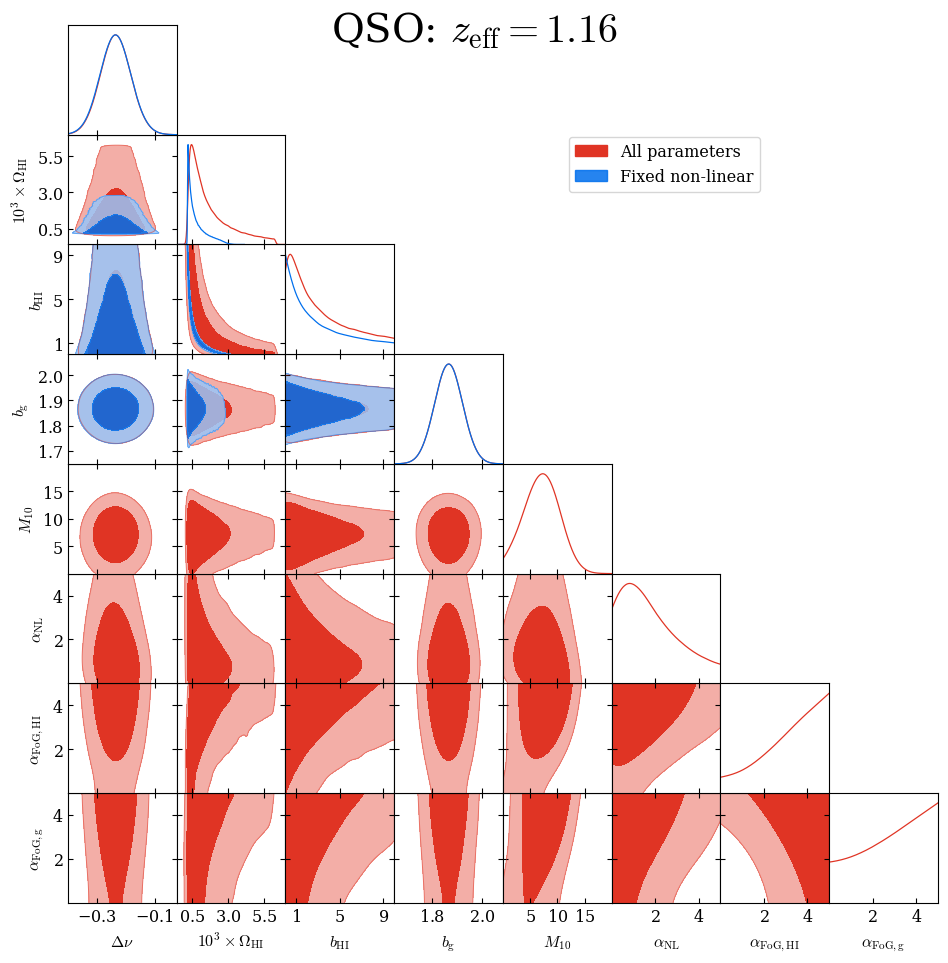

In [27]:
# Create plotter with larger size and better settings
g = plots.get_single_plotter(
    width_inch=10,           # Larger width for better readability
    scaling=True,
    ratio=1                  # Square aspect ratio
)

# Set additional GetDist-specific settings for publication quality
g.settings.axes_fontsize = 16        # Axis label font size
g.settings.lab_fontsize = 16         # Parameter label font size  
g.settings.legend_fontsize = 16      # Legend font size
#g.settings.colorbar_label_fontsize = 14
g.settings.title_limit_fontsize = 16

# Optional: Customize line widths and contour properties
g.settings.linewidth = 2.5           # Contour line width
g.settings.linewidth_contour = 2.0   # Filled contour edge width
g.settings.alpha_filled_add = 0.85   # Filled contour transparency

#label = fr"All parameters - $\chi^2_\mathrm{{min}} = {2 * chain.loglikes.min():.1f}$"
g.triangle_plot(
        [chain_all, chain_nlfix],
        orig_params,
        filled=True,
        #legend_loc="upper right",
        #legend_labels=[label],  
        legend_loc=(0.6, 0.8),
        #param_limits={"omegabfm2": omegabfm2_limits[tracer]},
    )
plt.suptitle(fr"{tracer.split('b')[0]}: $z_\mathrm{{eff}} = {z_eff:.2f}$", va="top")

if save:
    g.export(save_path+f"origparams_{tracer}_{weight}.pdf")
    g.export(save_path+f"origparams_{tracer}_{weight}.png")

# plot the reduced set of parameters and the correlated set of parameters as in the stacking paper 

<Figure size 1000x1000 with 0 Axes>

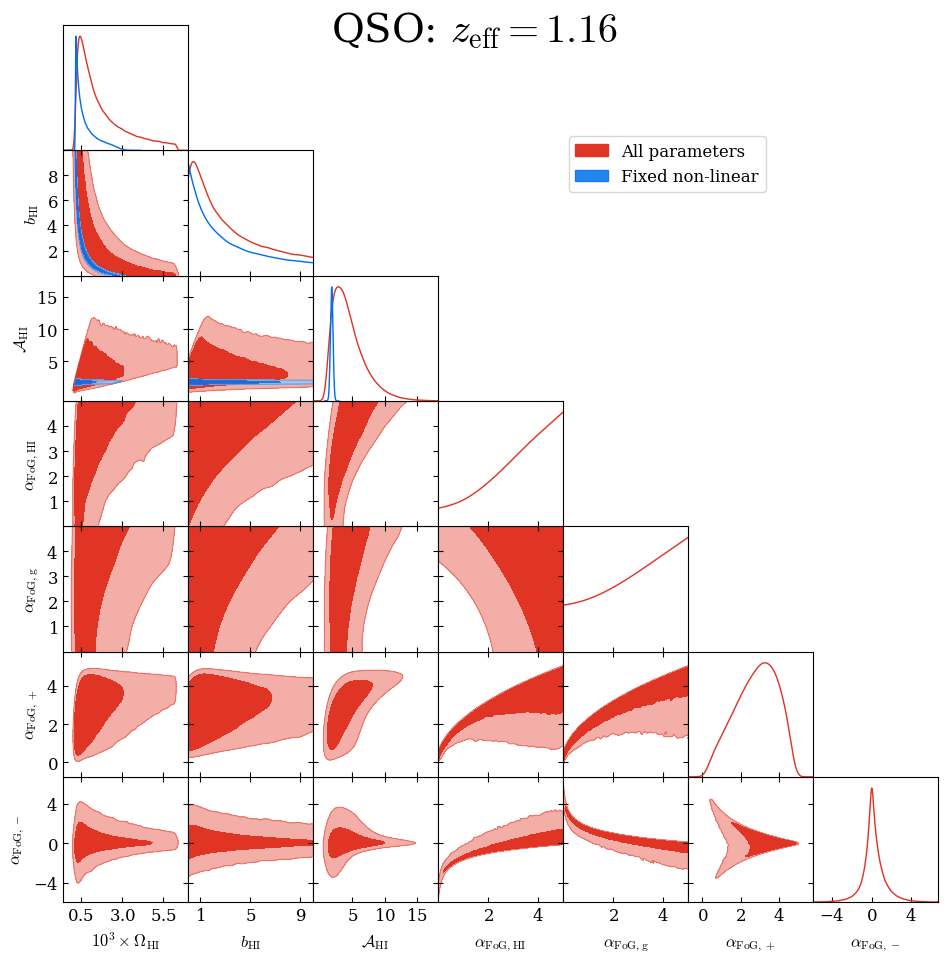

In [28]:
# Create plotter with larger size and better settings
g = plots.get_single_plotter(
    width_inch=10,           # Larger width for better readability
    scaling=True,
    ratio=1                  # Square aspect ratio
)

# Set additional GetDist-specific settings for publication quality
g.settings.axes_fontsize = 16        # Axis label font size
g.settings.lab_fontsize = 16         # Parameter label font size  
g.settings.legend_fontsize = 16      # Legend font size
#g.settings.colorbar_label_fontsize = 14
g.settings.title_limit_fontsize = 16

# Optional: Customize line widths and contour properties
g.settings.linewidth = 2.5           # Contour line width
g.settings.linewidth_contour = 2.0   # Filled contour edge width
g.settings.alpha_filled_add = 0.85   # Filled contour transparency

#label = fr"All parameters - $\chi^2_\mathrm{{min}} = {2 * chain.loglikes.min():.1f}$"
g.triangle_plot(
        [chain_all, chain_nlfix],
        corr_params,
        filled=True,
        legend_loc=(0.6, 0.8),
            )
plt.suptitle(fr"{tracer.split('b')[0]}: $z_\mathrm{{eff}} = {z_eff:.2f}$", va="top")

if save:
    g.export(save_path+f"corrparams_{tracer}_{weight}.pdf")
    g.export(save_path+f"corrparams_{tracer}_{weight}.png")

# plot only the reduced set of parameters

In [29]:
# reduced params plot 
new_params = [
    "offset",
    "omegabfm2",
    "M_10",
    "NL",
    "FoG+",
]

param_limits = {
    "omegabfm2": [0, 20],
    "offset": [-0.5, 0.5],
    "M_10": [0, 15],
    "NL": [0, 5],
    "FoG+": [0, 5],
}

omegabfm2_limits = {
    "QSObandb": [-0.5, 6.5],
}

In [30]:
chain_all.label = (
        fr"All parameters - $\chi^2_\mathrm{{min}} = {2 * chain_all.loglikes.min():.1f}$"
    )
chain_nlfix.label = (
        fr"Fixed non-linear - $\chi^2_\mathrm{{min}} = {2 * chain_nlfix.loglikes.min():.1f}$"
    )

<Figure size 1000x1000 with 0 Axes>

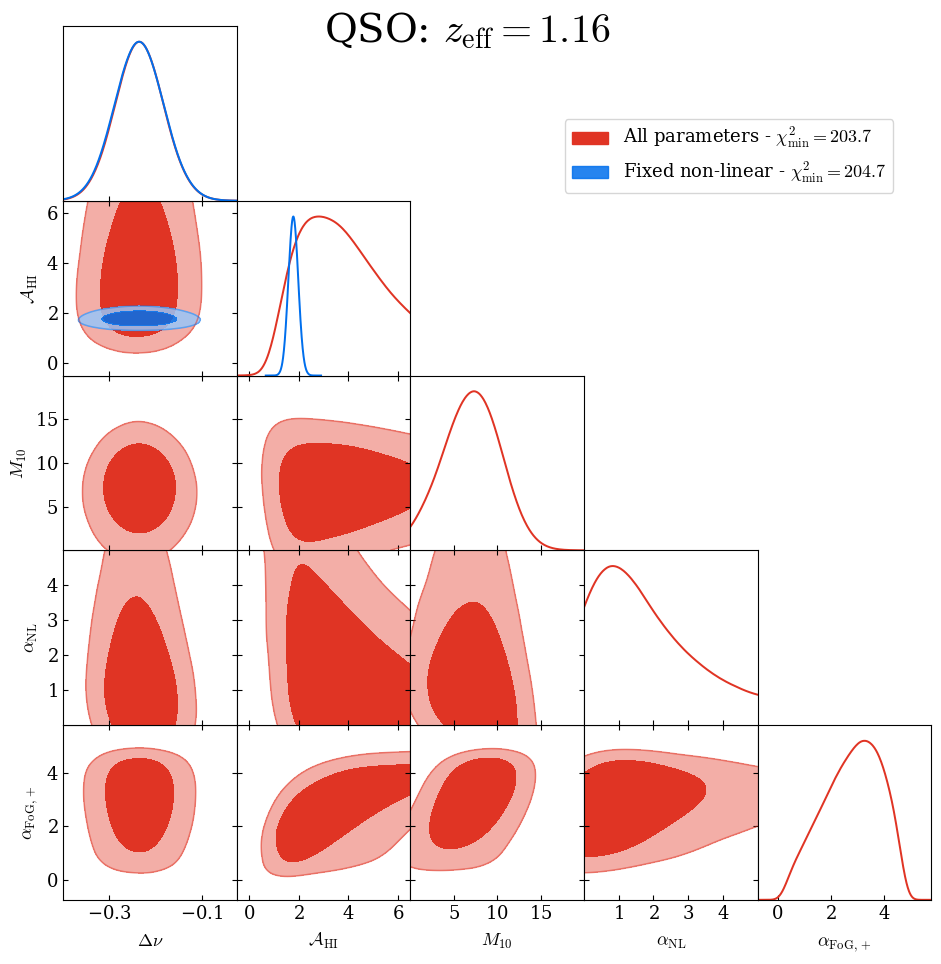

In [31]:
# Create plotter with larger size and better settings
g = plots.get_single_plotter(
    width_inch=10,           # Larger width for better readability
    scaling=True,
    ratio=1                  # Square aspect ratio
)

# Set additional GetDist-specific settings for publication quality
g.settings.axes_fontsize = 16        # Axis label font size
g.settings.lab_fontsize = 16         # Parameter label font size  
g.settings.legend_fontsize = 16      # Legend font size
#g.settings.colorbar_label_fontsize = 14
g.settings.title_limit_fontsize = 16

# Optional: Customize line widths and contour properties
g.settings.linewidth = 2.5           # Contour line width
g.settings.linewidth_contour = 2.0   # Filled contour edge width
g.settings.alpha_filled_add = 0.85   # Filled contour transparency

#label = fr"All parameters - $\chi^2_\mathrm{{min}} = {2 * chain.loglikes.min():.1f}$"
g.triangle_plot(
        [chain_all, chain_nlfix],
        new_params,
        filled=True,
        legend_loc=(0.6, 0.8),
        param_limits={"omegabfm2": omegabfm2_limits[chain_all.tracer]},
            )
plt.suptitle(fr"{tracer.split('b')[0]}: $z_\mathrm{{eff}} = {z_eff:.2f}$", va="top")

if save:
    g.export(save_path+f"reducedparams_{tracer}_{weight}.pdf")
    g.export(save_path+f"reducedparams_{tracer}_{weight}.png")

In [32]:
# Estimate the A_HI(stack) from the chain

In [33]:
mode_all, err_all = hpd_chain(chain_all,"omegabfm2")
print(mode_all, err_all)

2.8185925047113227 [1.4148266581213509, 2.6966553913460714]


In [34]:
mode_nlfix, err_nlfix = hpd_chain(chain_nlfix,"omegabfm2")
print(mode_nlfix, err_nlfix)

1.7773715369270857 [0.1969952588079238, 0.19916590309001703]


# Omega_HI constraint

# Add a prior on the value of b_HI of 20% fractional

In [35]:
llprior = 0.5 * ((chain_all["b_HI"] - 1.0) / 0.2) ** 2
llprior_fix = 0.5 * ((chain_nlfix["b_HI"] - 1.0) / 0.2) ** 2

In [36]:
re_weight = True
if re_weight:
    chain_all.reweightAddingLogLikes(llprior)
    chain_nlfix.reweightAddingLogLikes(llprior_fix)


In [37]:
z_range = config["QSObandb"]["z_range"]
z_range

[1.0006, 1.335]

In [38]:
za_eff = np.array(z_eff)
zerr_eff = np.abs(np.array([z_range]).T - za_eff)

In [39]:
za_eff, zerr_eff

(array(1.159286),
 array([[0.158686],
        [0.175714]]))

In [40]:
# param values of Omega_HI from the chain
ms_all, errsa_all = hpd_chain(chain_all, "omega_scaled")
ms_nlfix, errsa_nlfix = hpd_chain(chain_nlfix, "omega_scaled")

In [41]:
ms_all, errsa_all

(1.2395634461912997, [0.6098597743709715, 1.5086329788427901])

In [42]:
# Load other data
import yaml
with open("otherdata.yaml", "r") as fh:
    data = yaml.safe_load(fh)

In [43]:
# Process GBT numbers
# WiggleZ, ELG, LRG order
om_b_r = np.array([0.70, 0.55, 0.45])
errs = np.array([0.12, 0.11, 0.10])

r = np.array([0.9, 0.7, 0.6])
b_HI = 1 + lssmodels.bias["HI"](0.78)

om_GBT = om_b_r / b_HI / r

# Calculate errors for GBT, and add in a 20% uncertainty on the bias
err_GBT = om_GBT * ((errs / om_b_r)**2 + 0.2**2)**0.5
z_GBT = np.array([0.74, 0.78, 0.82])


types = [
    ("HI_direct", "HI direct", "o"),
    ("HI_stack", "HI stacking", "v"),
    ("HI_im", "HI intensity mapping", ">"),
    ("DLA", "Damped Lyman alpha", "s"),
]

c = cosmology.Cosmology()

In [44]:
markers = ["o", "v", "^", "<", ">", "8", "s", "p", "P", "*", "h", "X"]

In [45]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'  # or 'stix'
plt.rcParams.update({
    'font.size': 24,
    'axes.labelsize': 24,
    'axes.titlesize': 24,
    'xtick.labelsize': 24,
    'ytick.labelsize': 24
})

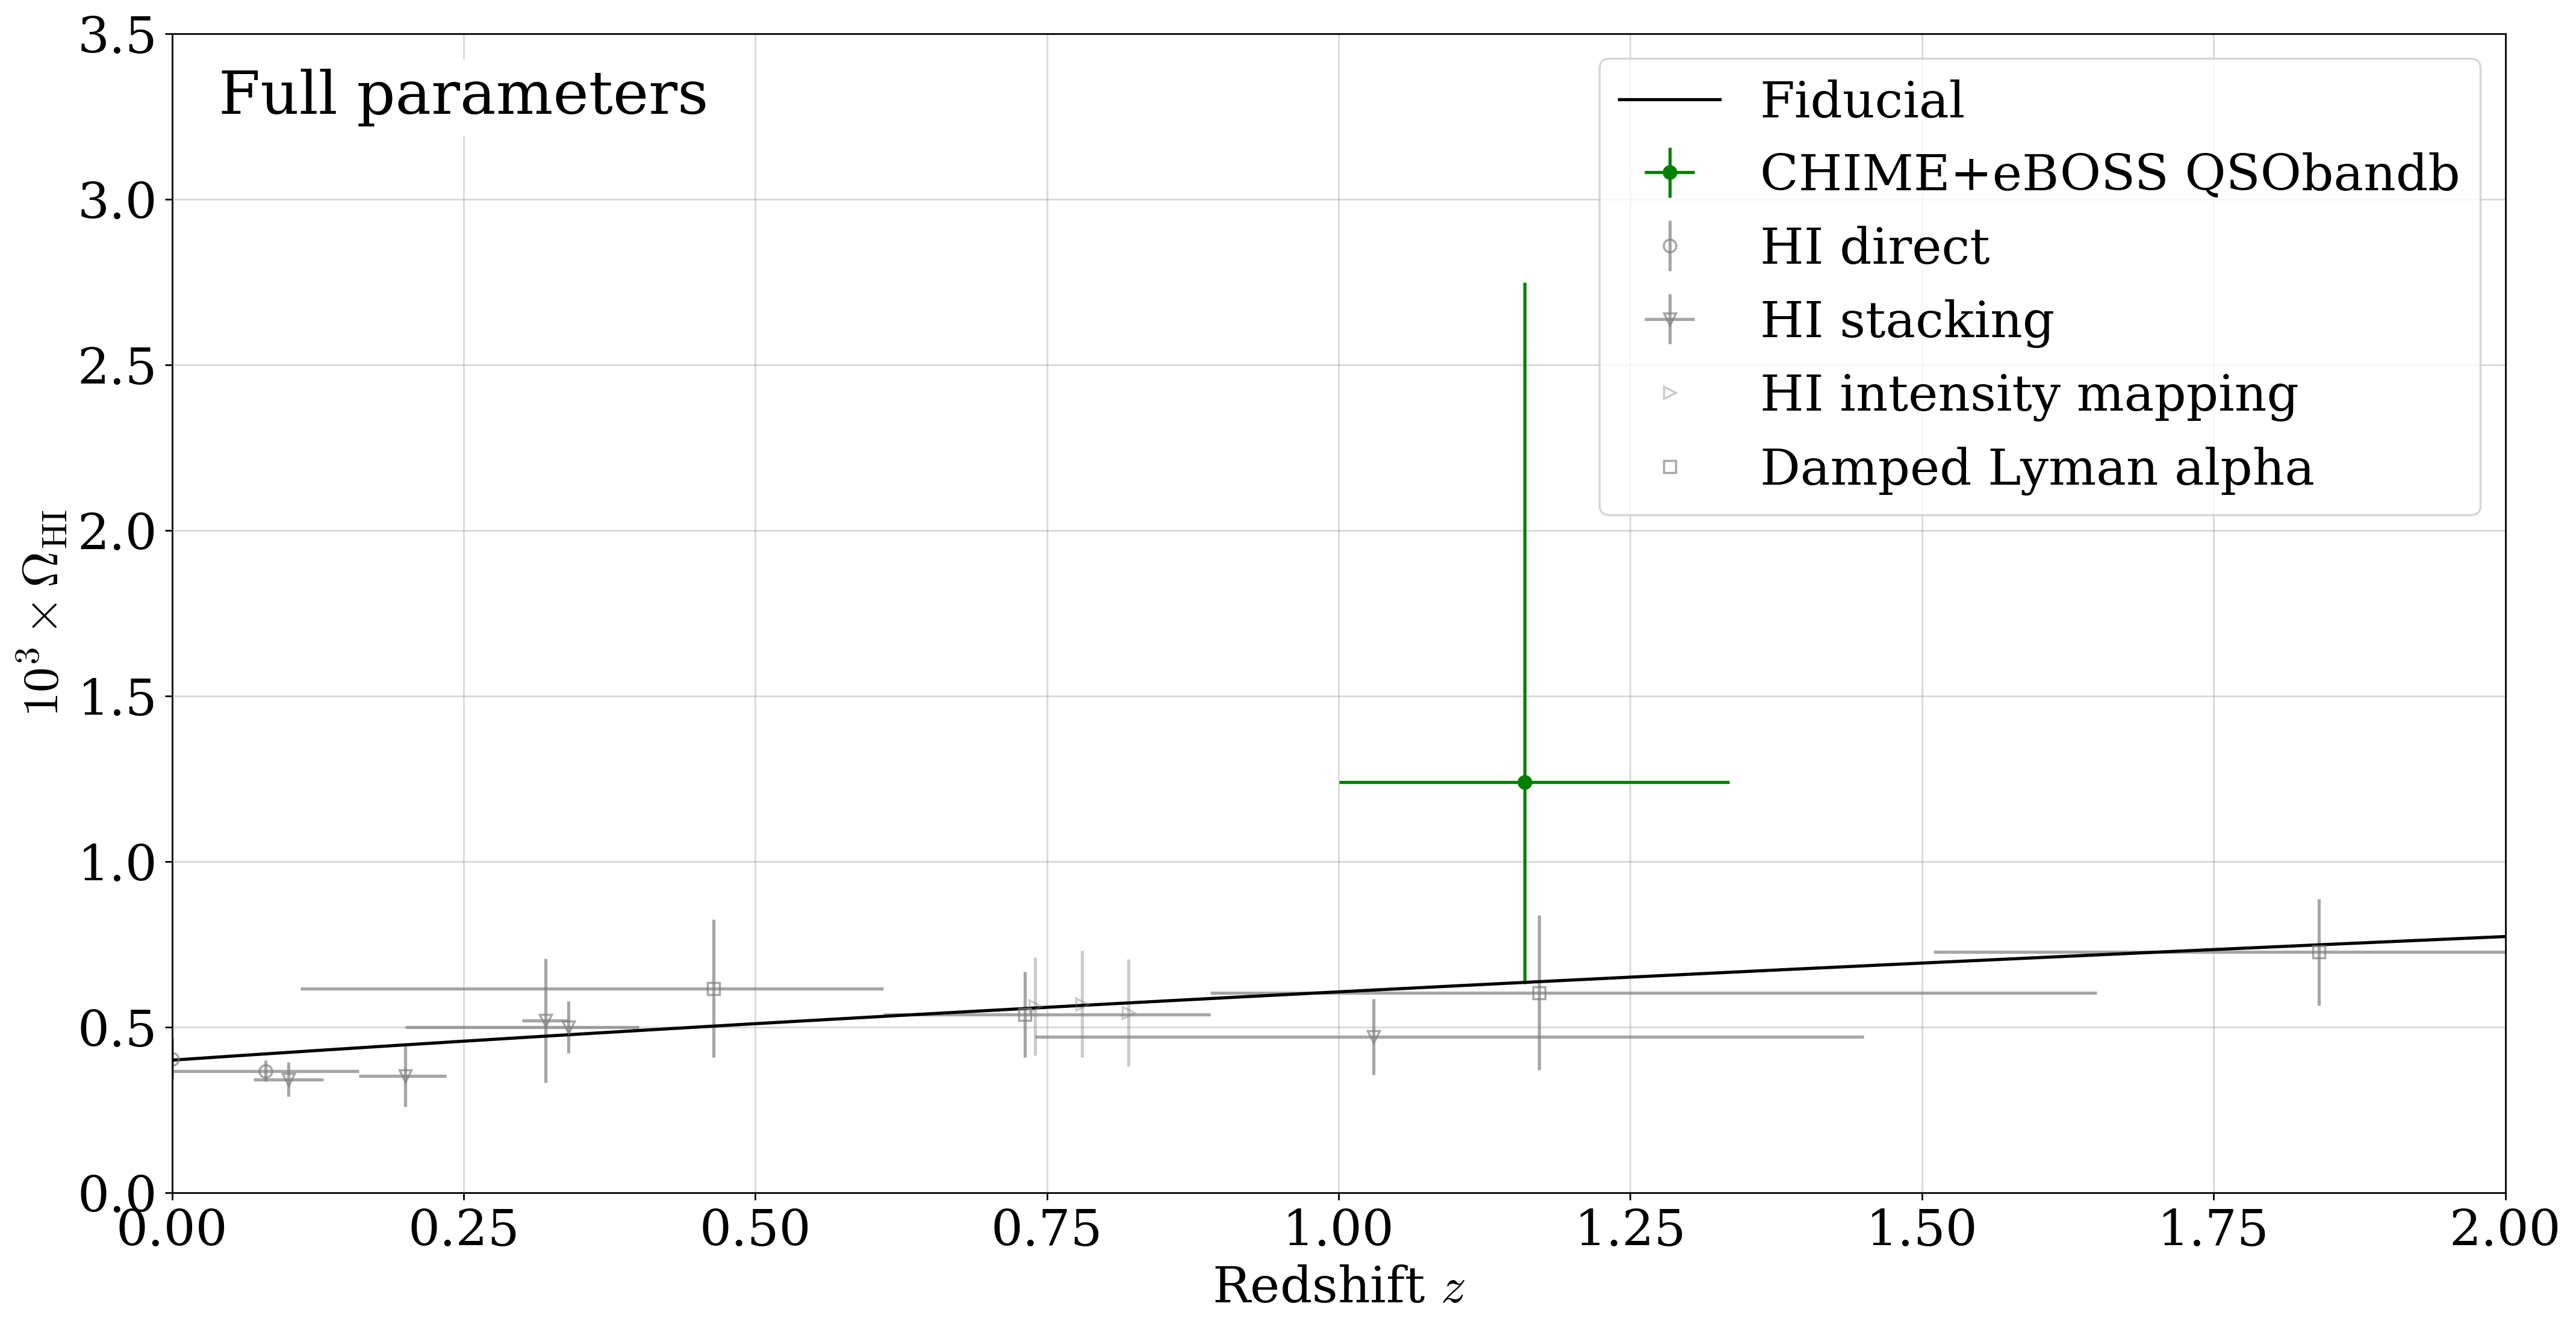

In [46]:
fig = plt.figure(num=1, figsize=(20, 10), dpi=250, linewidth=1.5)

# Create axes (assuming you want a single subplot, modify if you need multiple)
ax = plt.gca()

# plot the CHIME data
yerr = np.array([[errsa_all[0]], [errsa_all[1]]])
plt.errorbar(
    za_eff,
    ms_all,
    xerr=zerr_eff,
    yerr=yerr,
    marker='o',
    color='green',
    ls="",
    label=f"CHIME+eBOSS {tracer}",
)

# Now plot all other surveys 
for type_, label, marker in types:
    z = []
    om = []
    z_err = []
    om_err = []
    labelled = False
    if type_ == "HI_im":
        # Add in the GBT points by hand rather than trying to insert into the OmegaHI
        # data file
        plt.errorbar(
            z_GBT,
            om_GBT,
            xerr=None,
            yerr=err_GBT,
            label=label,
            marker=marker,
            markersize=6,
            ls="",
            color="gray",
            alpha=0.4,
            fillstyle="none",
        )
        continue
    for name, dset in data.items():
        if dset["type"] != type_:
            continue
        if type_ == "HI_stack" and name in ["delhaize2013", "chen2021"]:
            continue
        ds = combine_data(dset, cosmo=c)
        z = ds["z"]
        z_err = ds["zerr"]
        om = 1e3 * ds["omega_HI"]
        om_err = 1e3 * ds["omega_HI_err"]
        l = None if labelled else label
        labelled = True
        
        plt.errorbar(
            z,
            om,
            xerr=z_err,
            yerr=om_err,
            label=l,
            marker=marker,
            markersize=6,
            ls="",
            color="gray",
            alpha=0.7,
            fillstyle="none",
        )

za = np.linspace(0, 3)
omHI = lssmodels.omega_HI.evaluate(za)
plt.plot(za, 1e3 * omHI, "k-", label="Fiducial")

plt.xlim(0, 2)
plt.ylim(0, 3.5)
plt.xlabel("Redshift $z$")
plt.ylabel(r"$10^3 \times \Omega_\mathrm{HI}$")
plt.grid(color='gray', alpha=0.3)

## Fix up the legend
# get handles
handles, labels = ax.get_legend_handles_labels()
# remove the errorbars
handles = [h[0] if ii > 3 else h for ii, h in enumerate(handles)]
# use them in the legend
ax.legend(handles, labels, loc="upper right", ncol=1, numpoints=1)

# Add text labels (modify as needed for your specific case)
ax.text(
    0.02,
    1.0 - 0.03,
    "Full parameters",  # Change this label as needed
    transform=ax.transAxes,
    fontsize="large",
    bbox=dict(fc="w", ec="w"),
    verticalalignment="top",
)

if save: 
   plt.savefig(save_path+f"omegaHI_comparison_full_{tracer}_{weight}.pdf")
   plt.savefig(save_path+f"omegaHI_comparison_full_{tracer}_{weight}.png")

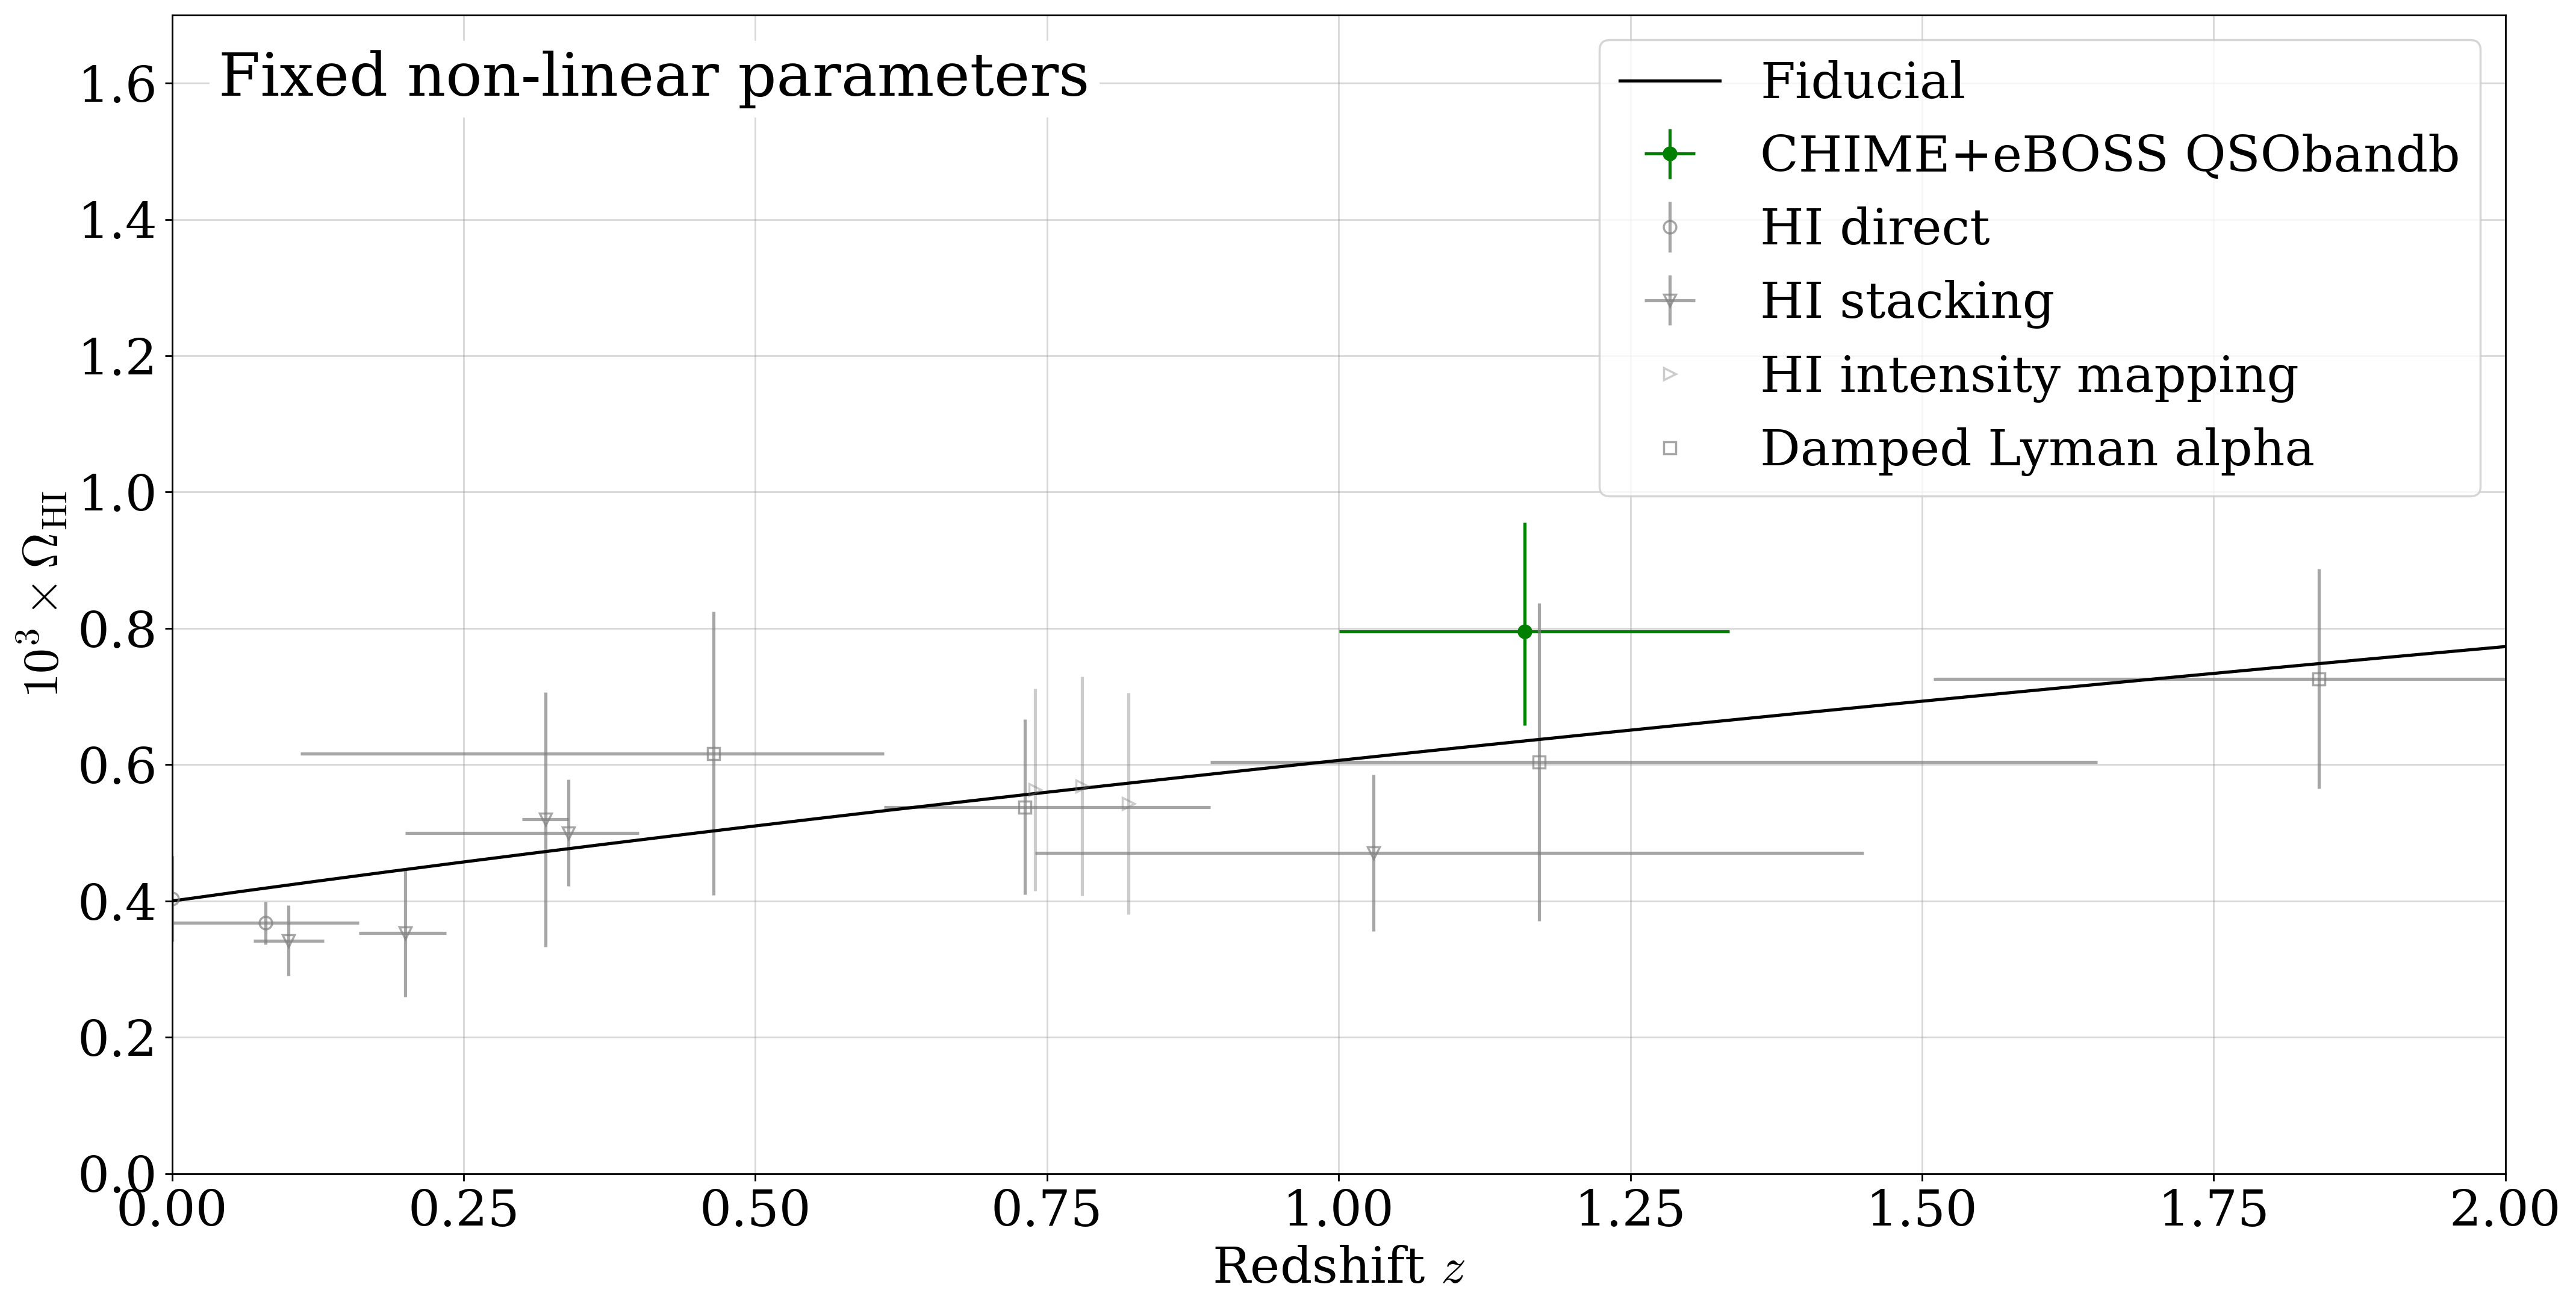

In [47]:
fig = plt.figure(num=1, figsize=(20, 10), dpi=250, linewidth=1.5)

# Create axes (assuming you want a single subplot, modify if you need multiple)
ax = plt.gca()

# plot the CHIME data
yerr = np.array([[errsa_nlfix[0]], [errsa_nlfix[1]]])
plt.errorbar(
    za_eff,
    ms_nlfix,
    xerr=zerr_eff,
    yerr=yerr,
    marker='o',
    color='green',
    ls="",
    label=f"CHIME+eBOSS {tracer}",
)

# Now plot all other surveys 
for type_, label, marker in types:
    z = []
    om = []
    z_err = []
    om_err = []
    labelled = False
    if type_ == "HI_im":
        # Add in the GBT points by hand rather than trying to insert into the OmegaHI
        # data file
        plt.errorbar(
            z_GBT,
            om_GBT,
            xerr=None,
            yerr=err_GBT,
            label=label,
            marker=marker,
            markersize=6,
            ls="",
            color="gray",
            alpha=0.4,
            fillstyle="none",
        )
        continue
    for name, dset in data.items():
        if dset["type"] != type_:
            continue
        if type_ == "HI_stack" and name in ["delhaize2013", "chen2021"]:
            continue
        ds = combine_data(dset, cosmo=c)
        z = ds["z"]
        z_err = ds["zerr"]
        om = 1e3 * ds["omega_HI"]
        om_err = 1e3 * ds["omega_HI_err"]
        l = None if labelled else label
        labelled = True
        
        plt.errorbar(
            z,
            om,
            xerr=z_err,
            yerr=om_err,
            label=l,
            marker=marker,
            markersize=6,
            ls="",
            color="gray",
            alpha=0.7,
            fillstyle="none",
        )

za = np.linspace(0, 3)
omHI = lssmodels.omega_HI.evaluate(za)
plt.plot(za, 1e3 * omHI, "k-", label="Fiducial")

plt.xlim(0, 2)
plt.ylim(0, 1.7)
plt.xlabel("Redshift $z$")
plt.ylabel(r"$10^3 \times \Omega_\mathrm{HI}$")
plt.grid(color='gray', alpha=0.3)

## Fix up the legend
# get handles
handles, labels = ax.get_legend_handles_labels()
# remove the errorbars
handles = [h[0] if ii > 3 else h for ii, h in enumerate(handles)]
# use them in the legend
ax.legend(handles, labels, loc="upper right", ncol=1, numpoints=1)

# Add text labels (modify as needed for your specific case)
ax.text(
    0.02,
    1.0 - 0.03,
    "Fixed non-linear parameters",  # Change this label as needed
    transform=ax.transAxes,
    fontsize="large",
    bbox=dict(fc="w", ec="w"),
    verticalalignment="top",
)

if save: 
   plt.savefig(save_path+f"omegaHI_comparison_fixed_{tracer}_{weight}.pdf")
   plt.savefig(save_path+f"omegaHI_comparison_fixed_{tracer}_{weight}.png")

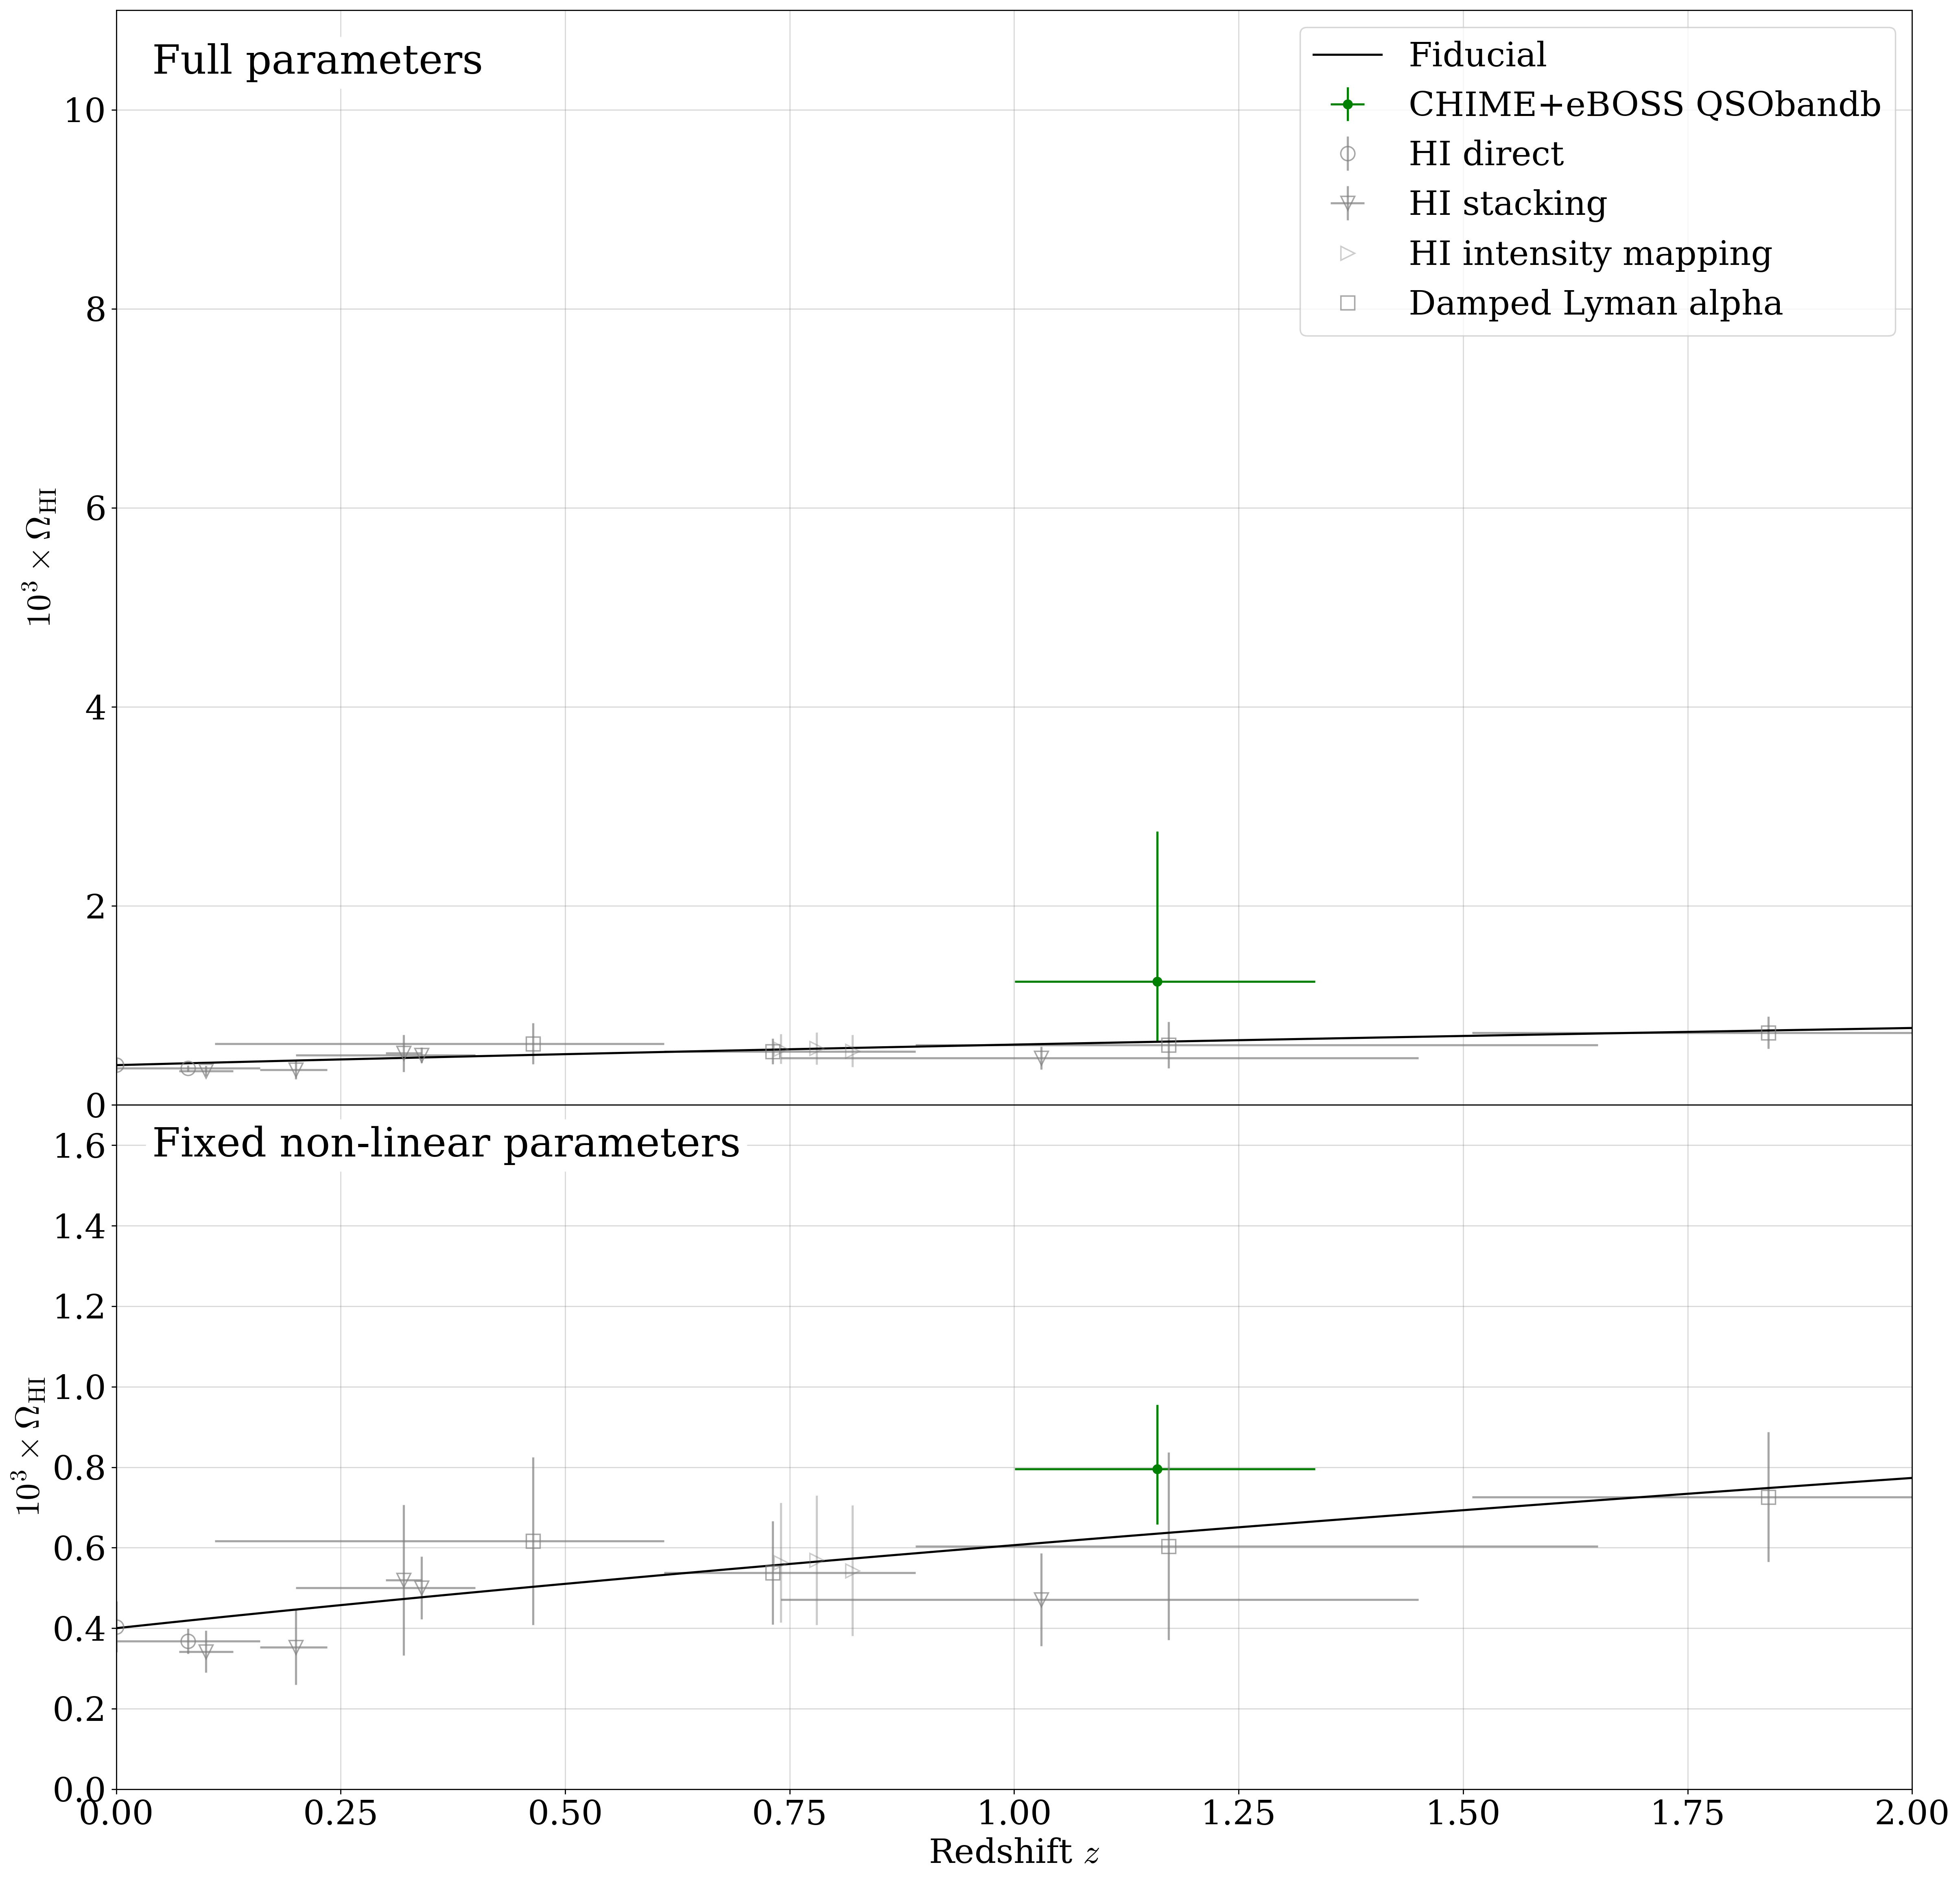

In [48]:
# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 19), dpi=250, 
                               sharex=True, 
                               gridspec_kw=dict(wspace=0.0, height_ratios=(1.6, 1), hspace=0.0))  

# Define data for each panel
panel_data = [
    {
        'ax': ax1,
        'ms_data': ms_all,
        'err_data': errsa_all,
        'ylim': (0, 11),
        'label': 'Full parameters'
    },
    {
        'ax': ax2,
        'ms_data': ms_nlfix,
        'err_data': errsa_nlfix,
        'ylim': (0, 1.7),
        'label': 'Fixed non-linear parameters'
    }
]

# Loop through each panel
for i, panel in enumerate(panel_data):
    ax = panel['ax']
    
    # Plot the CHIME data
    yerr = np.array([[panel['err_data'][0]], [panel['err_data'][1]]])
    ax.errorbar(
        za_eff,
        panel['ms_data'],
        xerr=zerr_eff,
        yerr=yerr,
        marker='o',
        color='green',
        ls="",
        label=f"CHIME+eBOSS {tracer}",
    )
    
    # Now plot all other surveys 
    for type_, label, marker in types:
        z = []
        om = []
        z_err = []
        om_err = []
        labelled = False
        
        if type_ == "HI_im":
            # Add in the GBT points by hand rather than trying to insert into the OmegaHI
            # data file
            ax.errorbar(
                z_GBT,
                om_GBT,
                xerr=None,
                yerr=err_GBT,
                label=label,
                marker=marker,
                markersize=10,
                ls="",
                color="gray",
                alpha=0.4,
                fillstyle="none",
            )
            continue
            
        for name, dset in data.items():
            if dset["type"] != type_:
                continue
            if type_ == "HI_stack" and name in ["delhaize2013", "chen2021"]:
                continue
            ds = combine_data(dset, cosmo=c)
            z = ds["z"]
            z_err = ds["zerr"]
            om = 1e3 * ds["omega_HI"]
            om_err = 1e3 * ds["omega_HI_err"]
            l = None if labelled else label
            labelled = True
            
            ax.errorbar(
                z,
                om,
                xerr=z_err,
                yerr=om_err,
                label=l,
                marker=marker,
                markersize=10,
                ls="",
                color="gray",
                alpha=0.7,
                fillstyle="none",
            )
    
    # Plot fiducial model
    za = np.linspace(0, 3)
    omHI = lssmodels.omega_HI.evaluate(za)
    ax.plot(za, 1e3 * omHI, "k-", label="Fiducial")
    
    # Set axis properties
    ax.set_xlim(0, 2)
    ax.set_ylim(panel['ylim'])
    ax.set_ylabel(r"$10^3 \times \Omega_\mathrm{HI}$")
    ax.grid(color='gray', alpha=0.3)
    
    # Fix up the legend (only for top panel)
    if i == 0:  # Only add legend to the first (top) panel
        handles, labels = ax.get_legend_handles_labels()
        # remove the errorbars
        handles = [h[0] if ii > 3 else h for ii, h in enumerate(handles)]
        # use them in the legend
        ax.legend(handles, labels, loc="upper right", ncol=1, numpoints=1)
    
    # Add text labels
    ax.text(
        0.02,
        1.0 - 0.03,
        panel['label'],
        transform=ax.transAxes,
        fontsize="large",
        bbox=dict(fc="w", ec="w"),
        verticalalignment="top",
    )

# Add x-label only to bottom panel
ax2.set_xlabel("Redshift $z$")

# # Adjust layout and display
plt.tight_layout()
# plt.show()

if save: 
   plt.savefig(save_path+f"omegaHI_comparison_{tracer}_{weight}.pdf",dpi=250,bbox_inches="tight")
   plt.savefig(save_path+f"omegaHI_comparison_{tracer}_{weight}.png",dpi=250,bbox_inches="tight")